# 01 — Exploratory Data Analysis

## Setup

Connect to Postgres using credentials from `.env` (never hardcoded — see
CLAUDE.md's Secrets section). Load the jupysql extension so SQL cells are
first-class citizens in this notebook instead of strings buried inside
`pd.read_sql`.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext sql

Build a SQLAlchemy engine from env vars and hand it to jupysql (jupysql
needs an `Engine` object, not a bare connection string, to reuse an existing
connection). `autopandas` stays off — pull to pandas explicitly, and only
for cells that need a chart or a stats test, per CLAUDE.md's tool rules.

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

user = quote_plus(os.environ["PGUSER"])
password = quote_plus(os.environ["PGPASSWORD"])
conn_str = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
)
engine = create_engine(conn_str)

%sql engine
%config SqlMagic.displaylimit = 20
%config SqlMagic.feedback = False
%config SqlMagic.autopandas = False

## Load and profile

First pass at unfamiliar data: how many rows, what date range, what do the
columns actually contain, and does anything look malformed. `ground_truth`
is deliberately excluded from every query in this notebook — this is blind
exploration, not a check against known answers.

Row counts for every table except `ground_truth`.

In [3]:
%%sql
SELECT 'journal_header' AS table_name, COUNT(*) AS n_rows FROM journal_header
UNION ALL SELECT 'journal_line', COUNT(*) FROM journal_line
UNION ALL SELECT 'bank_transactions', COUNT(*) FROM bank_transactions
UNION ALL SELECT 'dim_account', COUNT(*) FROM dim_account
UNION ALL SELECT 'dim_employee', COUNT(*) FROM dim_employee
UNION ALL SELECT 'dim_date', COUNT(*) FROM dim_date
ORDER BY 1;

table_name,n_rows
bank_transactions,52988
dim_account,27
dim_date,731
dim_employee,40
journal_header,113981
journal_line,256602


Date range and posting-time span. `transaction_date` (when the
underlying event happened) and `posting_datetime` (when it was recorded)
are two different clocks in this schema — worth seeing their raw range
before looking at the lag between them later in the Temporal section.

In [4]:
%%sql
SELECT
    MIN(posting_datetime)    AS min_posting,
    MAX(posting_datetime)    AS max_posting,
    MIN(transaction_date)    AS min_txn_date,
    MAX(transaction_date)    AS max_txn_date,
    COUNT(DISTINCT date_key) AS distinct_posting_days
FROM journal_header;

min_posting,max_posting,min_txn_date,max_txn_date,distinct_posting_days
2024-01-01 00:24:54,2026-01-28 12:32:14,2023-11-19,2026-01-28,731


Null rates and cardinality on `journal_header`. The only nullable
columns are `entry_description` and `reversed_header_id` (the latter is
only ever set on a correcting entry).

In [5]:
%%sql
SELECT
    COUNT(*)                                            AS n_rows,
    COUNT(*) FILTER (WHERE entry_description IS NULL)   AS null_entry_description,
    COUNT(*) FILTER (WHERE reversed_header_id IS NULL)  AS null_reversed_header_id,
    COUNT(*) FILTER (WHERE is_reversal)                 AS n_reversal_entries,
    COUNT(DISTINCT source_system)                       AS distinct_source_systems,
    COUNT(DISTINCT employee_key)                        AS distinct_employees
FROM journal_header;

n_rows,null_entry_description,null_reversed_header_id,n_reversal_entries,distinct_source_systems,distinct_employees
113981,0,112370,1611,5,39


`source_system` values and their share of posting volume.

In [6]:
%%sql
SELECT
    source_system,
    COUNT(*) AS n_headers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM journal_header
GROUP BY source_system
ORDER BY n_headers DESC;

source_system,n_headers,pct
AP,58260,51.1
AR,38787,34.0
Payroll,7321,6.4
GL_MANUAL,7138,6.3
GL,2475,2.2


`journal_line`: description null rate, plus two checks that should be
rare or zero for a well-formed ledger — a line carrying both a debit and a
credit at once, and a line carrying neither.

In [7]:
%%sql
SELECT
    COUNT(*)                                                       AS n_lines,
    COUNT(*) FILTER (WHERE line_description IS NULL)               AS null_line_description,
    COUNT(*) FILTER (WHERE debit_amount > 0 AND credit_amount > 0) AS both_debit_and_credit,
    COUNT(*) FILTER (WHERE debit_amount = 0 AND credit_amount = 0) AS zero_amount_lines
FROM journal_line;

n_lines,null_line_description,both_debit_and_credit,zero_amount_lines
256602,0,0,0


`bank_transactions`: null rates on `reference`/`counterparty`, plus
reference string length. CLAUDE.md flags these fields as deliberately
messy (abbreviations, truncation, dropped invoice numbers) so an exact-match
join to the ledger fails on most rows — nulls and short/garbled values here
are expected, not a data quality bug.

In [8]:
%%sql
SELECT
    COUNT(*)                                     AS n_txns,
    COUNT(*) FILTER (WHERE reference IS NULL)    AS null_reference,
    COUNT(*) FILTER (WHERE counterparty IS NULL) AS null_counterparty,
    MIN(LENGTH(reference))                       AS min_reference_len,
    MAX(LENGTH(reference))                       AS max_reference_len,
    MIN(value_date)                               AS min_value_date,
    MAX(value_date)                               AS max_value_date
FROM bank_transactions;

n_txns,null_reference,null_counterparty,min_reference_len,max_reference_len,min_value_date,max_value_date
52988,0,0,10,52,2024-01-01,2026-01-31


Cardinality of the categorical fields on `dim_account` and `dim_employee`.

In [9]:
%%sql
SELECT 'account_type' AS field, account_type AS value, COUNT(*) AS n
FROM dim_account GROUP BY account_type
UNION ALL
SELECT 'normal_balance', normal_balance, COUNT(*)
FROM dim_account GROUP BY normal_balance
ORDER BY field, n DESC;

field,value,n
account_type,Expense,10
account_type,Asset,7
account_type,Liability,5
account_type,Revenue,3
account_type,Equity,2
normal_balance,Debit,16
normal_balance,Credit,11


In [10]:
%%sql
SELECT 'department' AS field, department AS value, COUNT(*) AS n
FROM dim_employee GROUP BY department
UNION ALL
SELECT 'seniority_level', seniority_level, COUNT(*)
FROM dim_employee GROUP BY seniority_level
ORDER BY field, n DESC;

field,value,n
department,GL,7
department,Payroll,7
department,AR,7
department,AP,7
department,FP&A,6
department,Treasury,6
seniority_level,senior,18
seniority_level,mid,12
seniority_level,junior,10


Anything malformed? Three checks that should come back at or near
zero if the ledger is well-formed: headers with no lines at all, negative
amounts (blocked by a CHECK constraint at the DB level, but worth
confirming it held), and headers missing a required dimension key.

In [11]:
%%sql
SELECT
    (SELECT COUNT(*) FROM journal_header h
     WHERE NOT EXISTS (SELECT 1 FROM journal_line l WHERE l.header_id = h.header_id))
        AS headers_with_no_lines,
    (SELECT COUNT(*) FROM journal_line WHERE debit_amount < 0 OR credit_amount < 0)
        AS negative_amount_lines,
    (SELECT COUNT(*) FROM journal_header WHERE employee_key IS NULL OR date_key IS NULL)
        AS headers_missing_required_fk;

headers_with_no_lines,negative_amount_lines,headers_missing_required_fk
0,0,0


## Univariate

One variable at a time: the amount distribution, how volume spreads across
accounts and users, how many lines a typical entry carries, and whether the
ledger actually balances.

Header-level amount: the average of the debit-side and credit-side
total per entry (for a balanced entry these are equal, so this is a safe
single number per header without picking a side arbitrarily — same logic
as `total_amount` in the Phase 2 feature table). Capturing to a variable
with `<<` since this cell needs a chart, not a table.

In [12]:
%%sql amount_rs <<
SELECT
    h.header_id,
    ROUND(SUM(l.debit_amount + l.credit_amount) / 2, 2)::float8 AS total_amount
FROM journal_header h
JOIN journal_line l ON l.header_id = h.header_id
GROUP BY h.header_id;

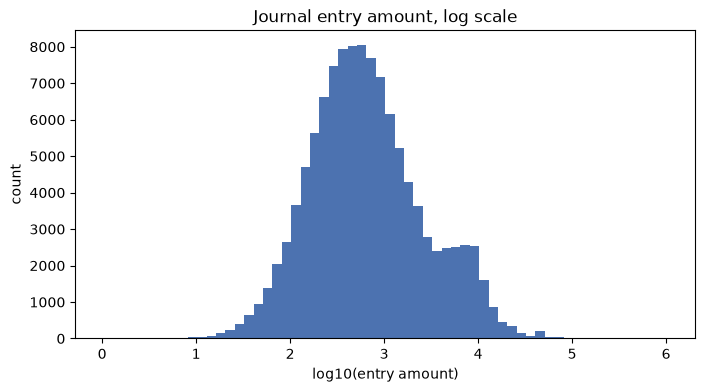

count    1.139810e+05
mean     1.972085e+03
std      6.726425e+03
min      1.030000e+00
25%      2.522000e+02
50%      5.829500e+02
75%      1.522770e+03
max      1.021496e+06
Name: total_amount, dtype: float64

In [13]:
import numpy as np
import matplotlib.pyplot as plt

amount_df = amount_rs.DataFrame()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(amount_df["total_amount"].clip(lower=0.01)), bins=60, color="#4C72B0")
ax.set_xlabel("log10(entry amount)")
ax.set_ylabel("count")
ax.set_title("Journal entry amount, log scale")
plt.show()

amount_df["total_amount"].describe()

Entries per account (line count by account) — where does posting volume concentrate?

In [14]:
%%sql acct_count_rs <<
SELECT a.account_id, a.account_name, a.account_type, COUNT(*) AS n_lines
FROM journal_line l
JOIN dim_account a ON a.account_key = l.account_key
GROUP BY a.account_id, a.account_name, a.account_type
ORDER BY n_lines DESC;

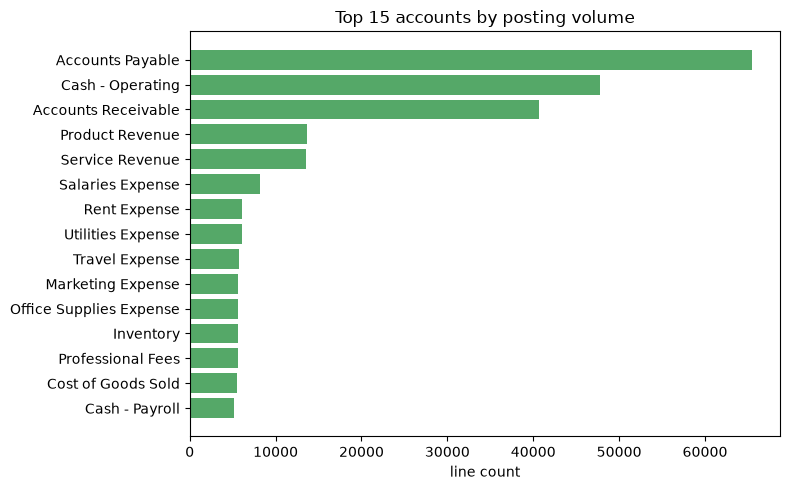

In [15]:
acct_count_df = acct_count_rs.DataFrame()
top15 = acct_count_df.head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top15["account_name"][::-1], top15["n_lines"][::-1], color="#55A868")
ax.set_xlabel("line count")
ax.set_title("Top 15 accounts by posting volume")
plt.tight_layout()
plt.show()

Entries per user (headers per employee) — is posting volume spread evenly or concentrated in a few preparers?

In [16]:
%%sql user_count_rs <<
SELECT e.employee_id, e.employee_name, e.role, COUNT(*) AS n_headers
FROM journal_header h
JOIN dim_employee e ON e.employee_key = h.employee_key
GROUP BY e.employee_id, e.employee_name, e.role
ORDER BY n_headers DESC;

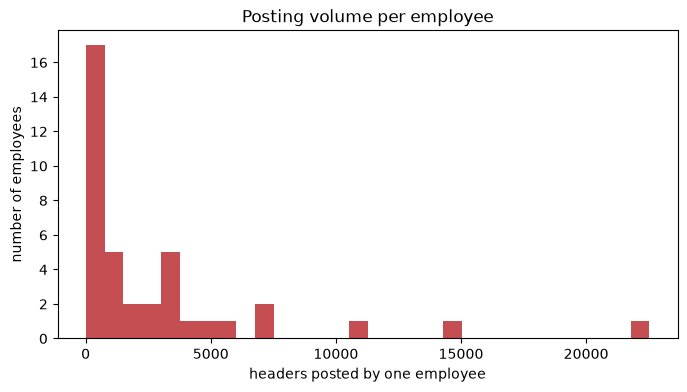

,employee_id,employee_name,role,n_headers
0,EMP0001,Alex Chen,AP Clerk,22531
1,EMP0002,Jordan Patel,AR Supervisor,14783
2,EMP0007,Riley Johnson,AP Clerk,11138
3,EMP0013,Reese Wilson,AP Clerk,7492
4,EMP0008,Jamie Brown,AR Supervisor,7414
5,EMP0019,Hayden Martin,AP Supervisor,5516
6,EMP0014,Rowan Anderson,AR Clerk,4988
7,EMP0025,Sawyer Lewis,AP Supervisor,4485
8,EMP0020,Peyton Lee,AR Supervisor,3748
9,EMP0031,Harper Wright,AP Clerk,3704


In [17]:
user_count_df = user_count_rs.DataFrame()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_count_df["n_headers"], bins=30, color="#C44E52")
ax.set_xlabel("headers posted by one employee")
ax.set_ylabel("number of employees")
ax.set_title("Posting volume per employee")
plt.show()

user_count_df.head(10)

Entry line counts — most journal entries should be simple 2-line debit/credit pairs; how common are multi-line entries?

In [18]:
%%sql line_count_rs <<
SELECT header_id, COUNT(*) AS n_lines
FROM journal_line
GROUP BY header_id;

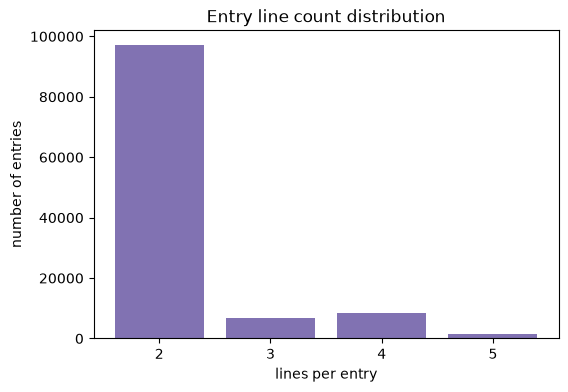

In [19]:
line_count_df = line_count_rs.DataFrame()
counts = line_count_df["n_lines"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index.astype(str), counts.values, color="#8172B2")
ax.set_xlabel("lines per entry")
ax.set_ylabel("number of entries")
ax.set_title("Entry line count distribution")
plt.show()

Debit/credit balance check: `SUM(debit_amount) - SUM(credit_amount)`
per header should be 0 for a well-formed entry. Counting how many headers
don't.

In [20]:
%%sql
SELECT
    (imbalance <> 0) AS is_unbalanced,
    COUNT(*)         AS n_headers
FROM (
    SELECT header_id, ROUND(SUM(debit_amount) - SUM(credit_amount), 2) AS imbalance
    FROM journal_line
    GROUP BY header_id
) t
GROUP BY 1;

is_unbalanced,n_headers
False,113643
True,338


## Temporal

When entries get posted: volume by day of month, hour of day, day of week,
and how far `transaction_date` lags behind `posting_datetime`.

Volume by day of month, split by `is_month_end` (dim_date's flag for
the last 3 business days of the month — those days differ month to month,
so this isn't just "day 28-31").

In [21]:
%%sql dom_rs <<
SELECT
    d.day AS day_of_month,
    d.is_month_end,
    COUNT(*) AS n_headers,
    ROUND(COUNT(*)::numeric / COUNT(DISTINCT d.calendar_date), 1) AS avg_headers_per_occurrence
FROM journal_header h
JOIN dim_date d ON d.date_key = h.date_key
GROUP BY d.day, d.is_month_end
ORDER BY d.day;

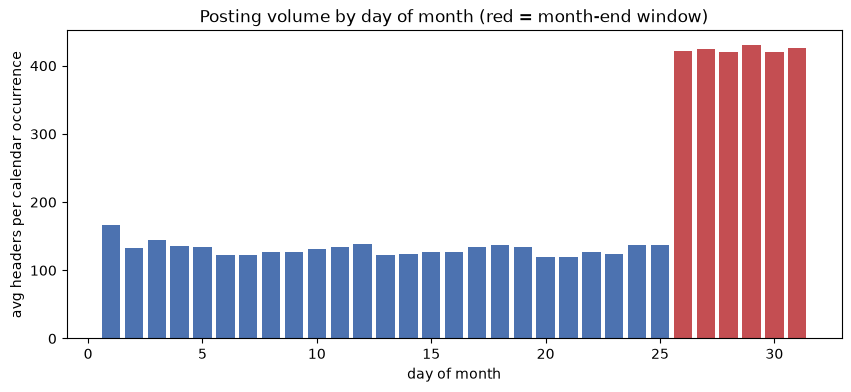

In [22]:
dom_df = dom_rs.DataFrame()
colors = dom_df["is_month_end"].map({True: "#C44E52", False: "#4C72B0"})

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dom_df["day_of_month"], dom_df["avg_headers_per_occurrence"], color=colors)
ax.set_xlabel("day of month")
ax.set_ylabel("avg headers per calendar occurrence")
ax.set_title("Posting volume by day of month (red = month-end window)")
plt.show()

Volume by hour of day, straight off `posting_datetime`.

In [23]:
%%sql hour_rs <<
SELECT EXTRACT(HOUR FROM posting_datetime)::int AS posting_hour, COUNT(*) AS n_headers
FROM journal_header
GROUP BY 1
ORDER BY 1;

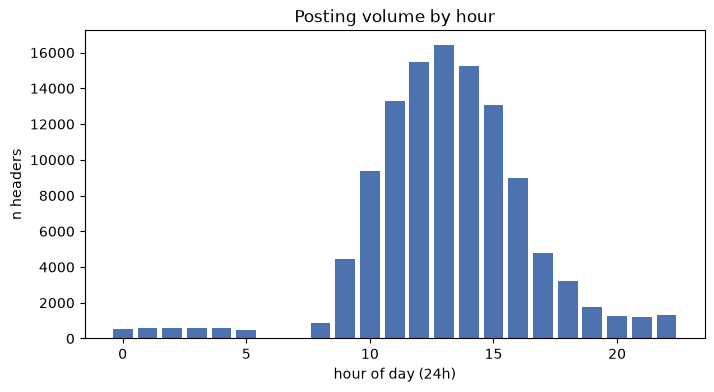

In [24]:
hour_df = hour_rs.DataFrame()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hour_df["posting_hour"], hour_df["n_headers"], color="#4C72B0")
ax.set_xlabel("hour of day (24h)")
ax.set_ylabel("n headers")
ax.set_title("Posting volume by hour")
plt.show()

Volume by day of week, using dim_date's `day_of_week`/`day_name` (0 = Monday) so ordering is correct without relying on locale.

In [25]:
%%sql dow_rs <<
SELECT d.day_of_week, d.day_name, COUNT(*) AS n_headers
FROM journal_header h
JOIN dim_date d ON d.date_key = h.date_key
GROUP BY d.day_of_week, d.day_name
ORDER BY d.day_of_week;

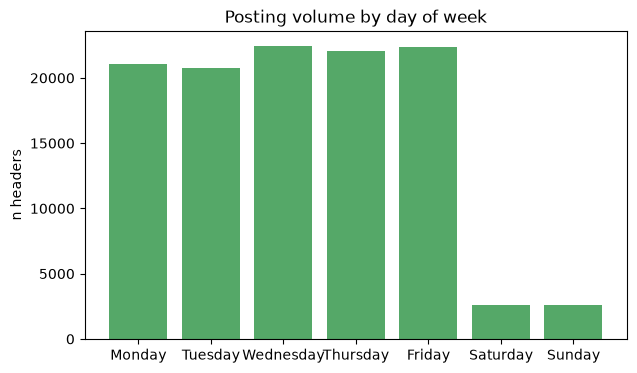

In [26]:
dow_df = dow_rs.DataFrame()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow_df["day_name"], dow_df["n_headers"], color="#55A868")
ax.set_ylabel("n headers")
ax.set_title("Posting volume by day of week")
plt.show()

Posting lag: `posting_datetime::date - transaction_date`, in days.
This is the raw distribution before any labelling — CLAUDE.md's data shape
notes say the baseline lag should cluster near 0, with a long tail, but
that's the generator's design intent, not something read off ground truth.
Worth seeing what the distribution actually looks like.

In [27]:
%%sql lag_rs <<
SELECT (posting_datetime::date - transaction_date) AS lag_days
FROM journal_header;

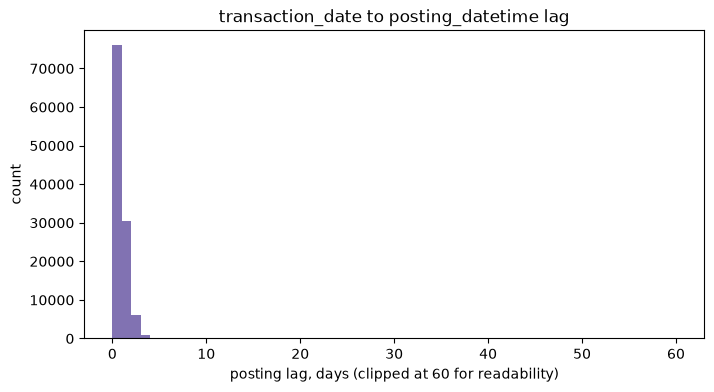

In [28]:
lag_df = lag_rs.DataFrame()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lag_df["lag_days"].clip(upper=60), bins=60, color="#8172B2")
ax.set_xlabel("posting lag, days (clipped at 60 for readability)")
ax.set_ylabel("count")
ax.set_title("transaction_date to posting_datetime lag")
plt.show()

In [29]:
%%sql
SELECT
    CASE
        WHEN lag_days <= 2  THEN '0-2 days'
        WHEN lag_days <= 9  THEN '3-9 days'
        WHEN lag_days <= 30 THEN '10-30 days'
        ELSE '31+ days'
    END AS lag_bucket,
    MIN(lag_days) AS min_lag,
    MAX(lag_days) AS max_lag,
    COUNT(*)      AS n_headers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM (SELECT posting_datetime::date - transaction_date AS lag_days FROM journal_header) t
GROUP BY 1
ORDER BY min_lag;

lag_bucket,min_lag,max_lag,n_headers,pct
0-2 days,0,2,112630,98.81
3-9 days,3,9,1068,0.94
10-30 days,10,30,174,0.15
31+ days,31,92,109,0.10


## Bivariate

Amount against account type, user role, and posting source — looking for
obvious splits before reaching for a formal test in Phase 4a.

Line-level amount by account type. Pulling raw line amounts (not header totals) since account_type is a line-level attribute.

In [30]:
%%sql acct_amount_rs <<
SELECT
    a.account_type,
    (l.debit_amount + l.credit_amount)::float8 AS line_amount
FROM journal_line l
JOIN dim_account a ON a.account_key = l.account_key
WHERE l.debit_amount + l.credit_amount > 0;

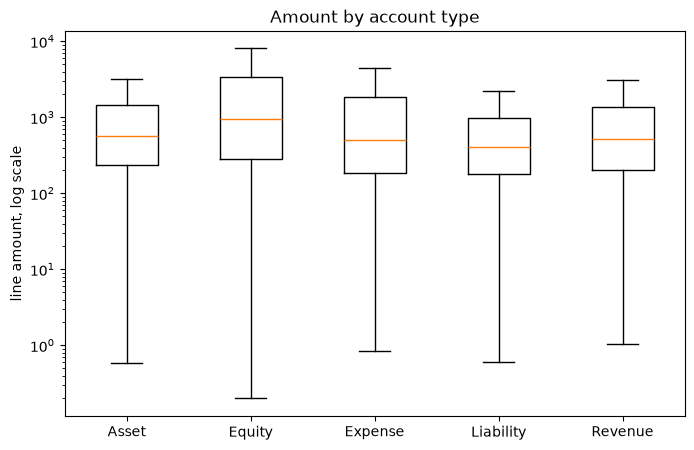

In [31]:
acct_amount_df = acct_amount_rs.DataFrame()
groups = [g["line_amount"].values for _, g in acct_amount_df.groupby("account_type")]
labels = sorted(acct_amount_df["account_type"].unique())

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("line amount, log scale")
ax.set_title("Amount by account type")
plt.show()

Header-level amount by preparer role.

In [32]:
%%sql role_amount_rs <<
SELECT
    e.role,
    ROUND(SUM(l.debit_amount + l.credit_amount) / 2, 2)::float8 AS total_amount
FROM journal_header h
JOIN dim_employee e ON e.employee_key = h.employee_key
JOIN journal_line l ON l.header_id = h.header_id
GROUP BY h.header_id, e.role;

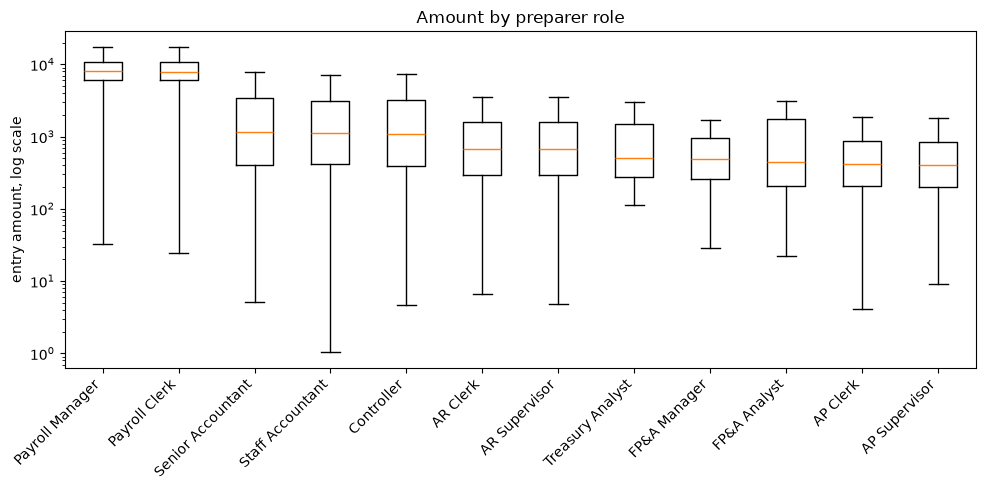

In [33]:
role_amount_df = role_amount_rs.DataFrame()
role_order = role_amount_df.groupby("role")["total_amount"].median().sort_values(ascending=False).index
groups = [role_amount_df.loc[role_amount_df["role"] == r, "total_amount"].values for r in role_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(groups, tick_labels=role_order, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("entry amount, log scale")
ax.set_title("Amount by preparer role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Manual vs. system source. `GL_MANUAL` is the one source_system value
posted directly by a human rather than generated by an upstream subsystem
(AP/AR/PAYROLL) — comparing amount and posting-hour patterns between the
two.

In [34]:
%%sql source_amount_rs <<
SELECT
    (source_system = 'GL_MANUAL') AS is_manual,
    ROUND(SUM(l.debit_amount + l.credit_amount) / 2, 2)::float8 AS total_amount
FROM journal_header h
JOIN journal_line l ON l.header_id = h.header_id
GROUP BY h.header_id, source_system;

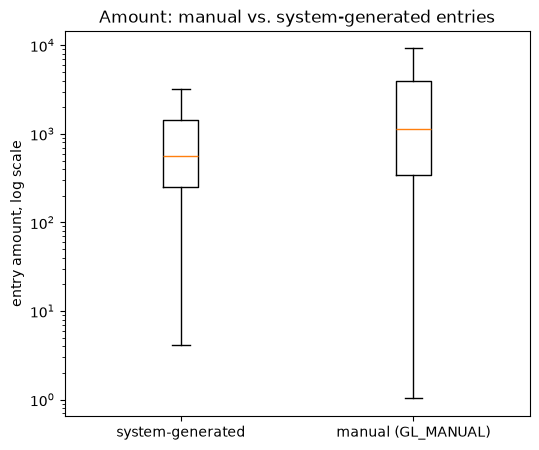

In [35]:
source_amount_df = source_amount_rs.DataFrame()
groups = [
    source_amount_df.loc[source_amount_df["is_manual"] == v, "total_amount"].values
    for v in [False, True]
]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(groups, tick_labels=["system-generated", "manual (GL_MANUAL)"], showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("entry amount, log scale")
ax.set_title("Amount: manual vs. system-generated entries")
plt.show()

In [36]:
%%sql
SELECT
    (source_system = 'GL_MANUAL')                        AS is_manual,
    COUNT(*)                                              AS n_headers,
    ROUND(AVG(EXTRACT(HOUR FROM posting_datetime)), 1)    AS avg_posting_hour,
    ROUND(100.0 * COUNT(*) FILTER (
        WHERE EXTRACT(HOUR FROM posting_datetime) NOT BETWEEN 8 AND 18
    ) / COUNT(*), 1)                                      AS pct_outside_8_to_18
FROM journal_header
GROUP BY 1;

is_manual,n_headers,avg_posting_hour,pct_outside_8_to_18
False,106843,13.1,7.8
True,7138,13.3,7.7


## Findings

1. **Scale and shape check out.** 113,981 headers / 256,602 lines, spanning
   2024-01-01 to 2026-01-28 (`transaction_date` reaches back to 2023-11-19
   for the backdated tail). The amount distribution is heavily right-skewed —
   median $582.95 vs. mean $1,972.09, max just over $1.02M — matching the
   log-normal shape in the amount histogram (Univariate section).

2. **The ledger is structurally clean.** Zero null `line_description`,
   zero negative amounts, zero lines carrying both a debit and a credit,
   zero headers with no lines, zero headers missing a required FK. 85.2%
   of entries (97,098) are simple 2-line debit/credit pairs; the rest run
   3-5 lines (entry line count chart, Univariate section).

3. **338 headers (0.3%) don't balance** — `SUM(debit) - SUM(credit) <> 0`
   for those headers, everything else nets to zero. Nothing else in this
   notebook explains which headers these are; they stand out purely on the
   balance check itself.

4. **Posting hours cluster hard around midday**, not just "business hours."
   The single busiest hour is 13:00 (16,416 headers), with 11:00-15:00 the
   dominant block (posting-hour bar chart, Temporal section) — a tighter
   cluster than a generic 08:00-18:00 window would suggest.

5. **Clear 5-day workweek.** Weekday volume runs 20,741-22,475 headers/day;
   Saturday and Sunday drop to ~2,630 each — a real but much smaller weekend
   tail, not zero (day-of-week chart, Temporal section).

6. **Month-end close spike is unmistakable.** `is_month_end` days average
   424.4 headers/day vs. 126.6 on other days — a ~3.4x concentration in a
   3-business-day window each month (day-of-month chart, Temporal section).

7. **Posting lag is dominated by 0-2 days (98.81%)**, with a long thin tail:
   0.94% at 3-9 days, 0.15% at 10-30 days, and 0.10% stretching out to a
   max of 92 days. The tail exists and is real, but it's a small slice of
   the whole (lag histogram + bucket table, Temporal section).

8. **Posting volume is very uneven across preparers.** The top employee
   (EMP0001, AP Clerk) alone posted 22,531 headers — about 20% of every
   entry in the ledger — far ahead of the next few employees. Volume per
   employee is not remotely flat (employee histogram, Univariate section).

9. **Line volume concentrates in a handful of accounts.** Accounts Payable,
   Cash - Operating, and Accounts Receivable account for 65,459 / 47,811 /
   40,686 lines respectively — any "how usual is this account for this
   entry" feature needs to account for wildly different baseline volumes
   per account (account bar chart, Univariate section).

10. **`account_type` alone is a weak amount discriminator.** Median line
    amount is close across types — Equity $962.95, Asset $561.58, Revenue
    $523.61, Expense $502.04, Liability $404.32 — and the boxplots show
    heavy overlap (Bivariate section). Account type on its own won't carry
    much weight for anomaly detection.

11. **Role is a much stronger amount split.** Payroll roles post far larger
    typical amounts — Payroll Manager median $8,073.91, Payroll Clerk
    $7,942.36 — against $400-700 for AP/AR clerk-level roles (role boxplot,
    Bivariate section). Makes sense for bulk payroll runs, but it's a real
    behavioral signal worth encoding as a feature.

12. **Manual entries run bigger but not later.** `GL_MANUAL` entries have
    roughly double the median amount of system-generated ones ($1,137.63
    vs. $564.62), but posting-hour behavior is nearly identical (13.3 vs.
    13.1 average hour, 7.7% vs. 7.8% outside 08:00-18:00). Amount and
    "manual" correlate; off-hours timing and "manual" don't — on their own.
    Worth checking whether the combination (manual *and* off-hours) is
    where the real signal lives, rather than either flag alone.
